In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [13]:
#Load Datasets
df_churn20 = pd.read_csv (r"C:\Users\user\OneDrive\Documents\churn-bigml-20.csv") 
df_churn80 = pd.read_csv (r"C:\Users\user\OneDrive\Documents\churn-bigml-80.csv")
print(df_churn20.head())
print(df_churn80.head())

  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95   

In [14]:
#Merge Datasets
df = pd.concat([df_churn20, df_churn80], axis=0)
print(df.shape)

(3333, 20)


In [ ]:
#Clean Dataset
df.info()
df.isnull().sum()
df.duplicated().sum()

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Handle missing values 
df = df.dropna() 

# Remove duplicates
df = df.drop_duplicates()

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float

In [16]:
#Exploratory Data Analysis
print(df.describe())



       account_length    area_code  number_vmail_messages  total_day_minutes  \
count     3333.000000  3333.000000            3333.000000        3333.000000   
mean       101.064806   437.182418               8.099010         179.775098   
std         39.822106    42.371290              13.688365          54.467389   
min          1.000000   408.000000               0.000000           0.000000   
25%         74.000000   408.000000               0.000000         143.700000   
50%        101.000000   415.000000               0.000000         179.400000   
75%        127.000000   510.000000              20.000000         216.400000   
max        243.000000   510.000000              51.000000         350.800000   

       total_day_calls  total_day_charge  total_eve_minutes  total_eve_calls  \
count      3333.000000       3333.000000        3333.000000      3333.000000   
mean        100.435644         30.562307         200.980348       100.114311   
std          20.069084          9.25943

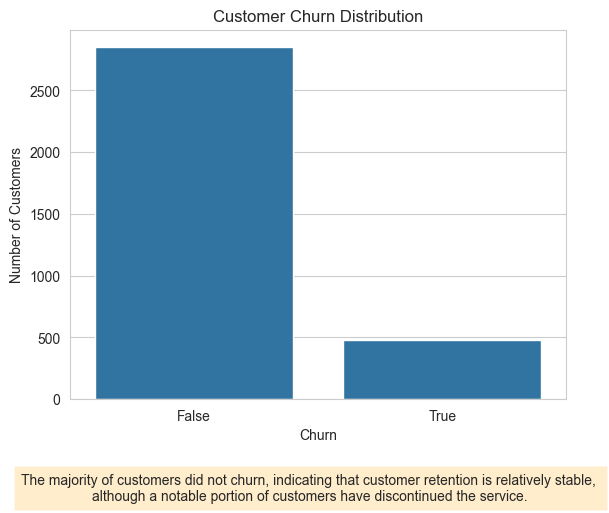

File exported successfully: customer_churn_distribution.csv


In [17]:
# Chart 1: Churn Distribution

customer_churn_distribution = df['churn'].value_counts().reset_index()
customer_churn_distribution.columns = ['Churn', 'Customer_Count']

sns.countplot(x='churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.figtext(0.5, -0.1, 
            "The majority of customers did not churn, indicating that customer retention is relatively stable, \n"
            "although a notable portion of customers have discontinued the service.", 
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.show()
customer_churn_distribution.to_csv("customer_churn_distribution.csv", index=False)

print("File exported successfully: customer_churn_distribution.csv")




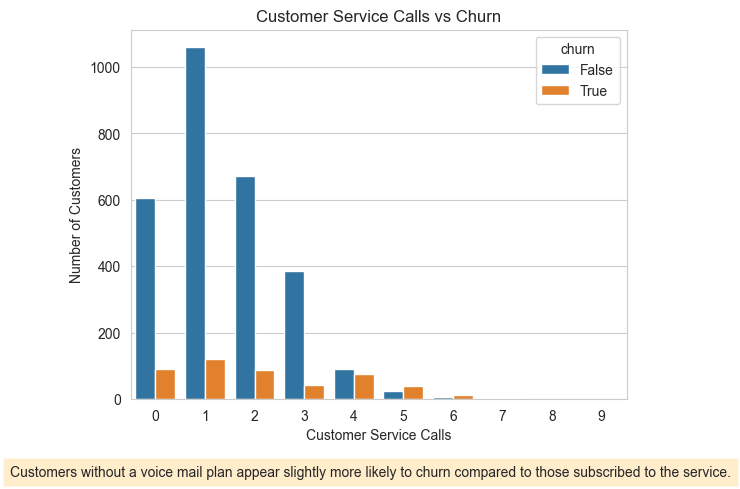

File exported successfully: customer_service_calls_churn.csv


In [18]:
#Chart 2: Customer Service Calls vs Churn 

customer_service_calls_churn = df.groupby(['customer_service_calls', 'churn']).size().reset_index(name='count')

sns.countplot(x='customer_service_calls', hue='churn', data=df)
plt.title("Customer Service Calls vs Churn")
plt.xlabel("Customer Service Calls")
plt.ylabel("Number of Customers")
plt.figtext(
    0.5, -0.05,
    "Customers without a voice mail plan appear slightly more likely to churn compared to those subscribed to the service.",
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}
)
plt.show()

# Export
customer_service_calls_churn.to_csv("customer_service_calls_churn.csv", index=False)
print("File exported successfully: customer_service_calls_churn.csv")

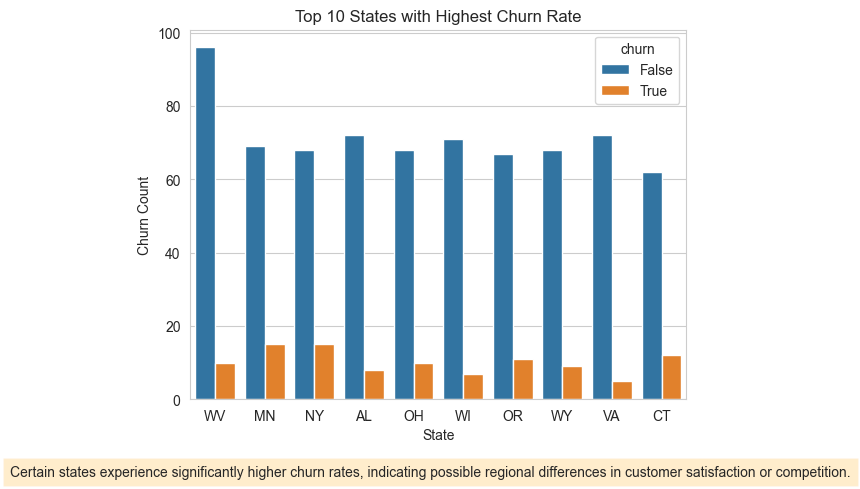

File exported successfully: churn_by_state.csv


In [27]:
#Chart 3: Top States by Churn

churn_by_state = df.groupby(['state', 'churn']).size().reset_index(name='count')

# Select top 10 states by total churn
state_churn_totals = churn_by_state.groupby('state')['count'].sum().sort_values(ascending=False).head(10).index
top_churn_df = df[df['state'].isin(state_churn_totals)]

sns.countplot(x='state', hue='churn', data=top_churn_df, order=state_churn_totals)
plt.title("Top 10 States with Highest Churn Rate")
plt.xlabel("State")
plt.ylabel("Churn Count")
plt.figtext(
    0.5, -0.05,
    "Certain states experience significantly higher churn rates, indicating possible regional differences in customer satisfaction or competition.",
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}
)
plt.show()

# Export
churn_by_state.to_csv("churn_by_state.csv", index=False)
print("File exported successfully: churn_by_state.csv")

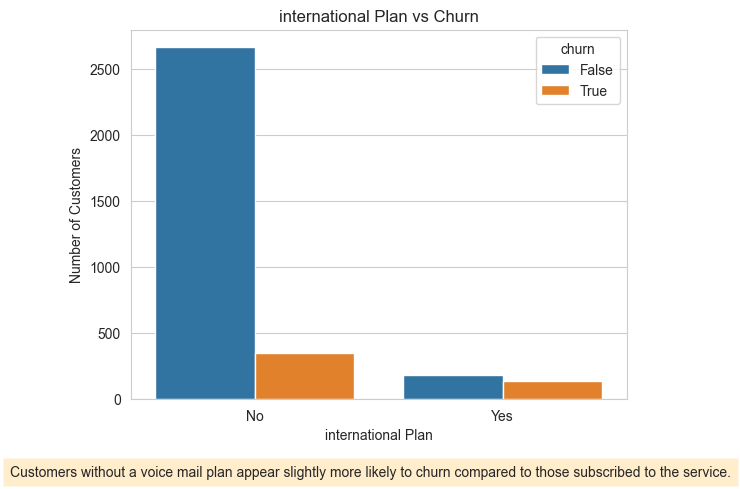

File exported successfully: international_plan_churn.csv


In [20]:
#Chart 4: International Plan vs Churn

international_plan_churn = df.groupby(['international_plan', 'churn']).size().reset_index(name='count')

# Plot
sns.countplot(x='international_plan', hue='churn', data=df)
plt.title("international Plan vs Churn")
plt.xlabel("international Plan")
plt.ylabel("Number of Customers")
plt.figtext(
    0.5, -0.05,
    "Customers without a voice mail plan appear slightly more likely to churn compared to those subscribed to the service.",
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}
)
plt.show()

# Export
international_plan_churn.to_csv("international_plan_churn.csv", index=False)
print("File exported successfully: international_plan_churn.csv")



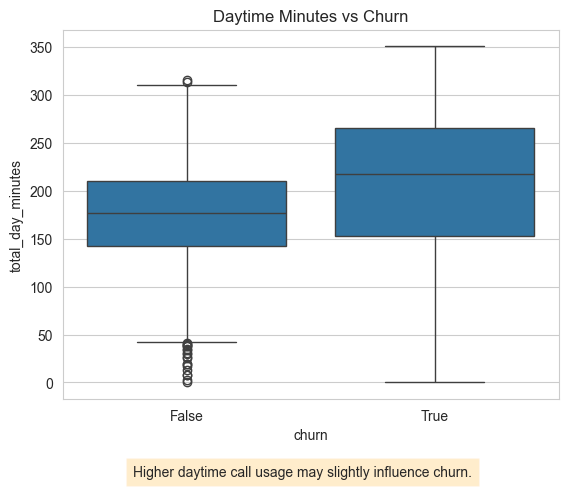

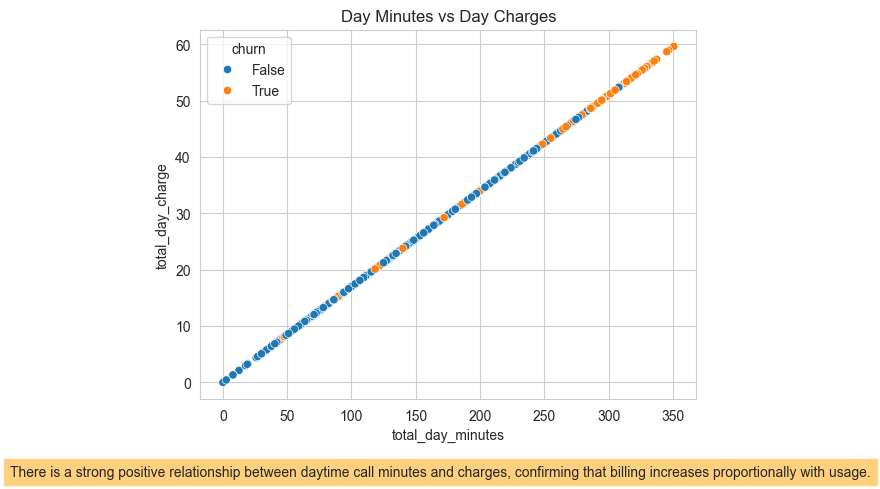

In [21]:
#Chart 5 — Boxplot (Usage vs Churn)
sns.boxplot(x='churn', y='total_day_minutes', data=df)
plt.title("Daytime Minutes vs Churn")
plt.figtext(0.5,-0.05,
            "Higher daytime call usage may slightly influence churn.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()

sns.scatterplot(x='total_day_minutes', y='total_day_charge', hue='churn', data=df)
plt.title("Day Minutes vs Day Charges")
plt.figtext(
    0.5, -0.05,
    "There is a strong positive relationship between daytime call minutes and charges, confirming that billing increases proportionally with usage.",
    ha="center",
    fontsize=10,
    bbox={"facecolor":"orange", "alpha":0.5, "pad":5}
)


plt.show()



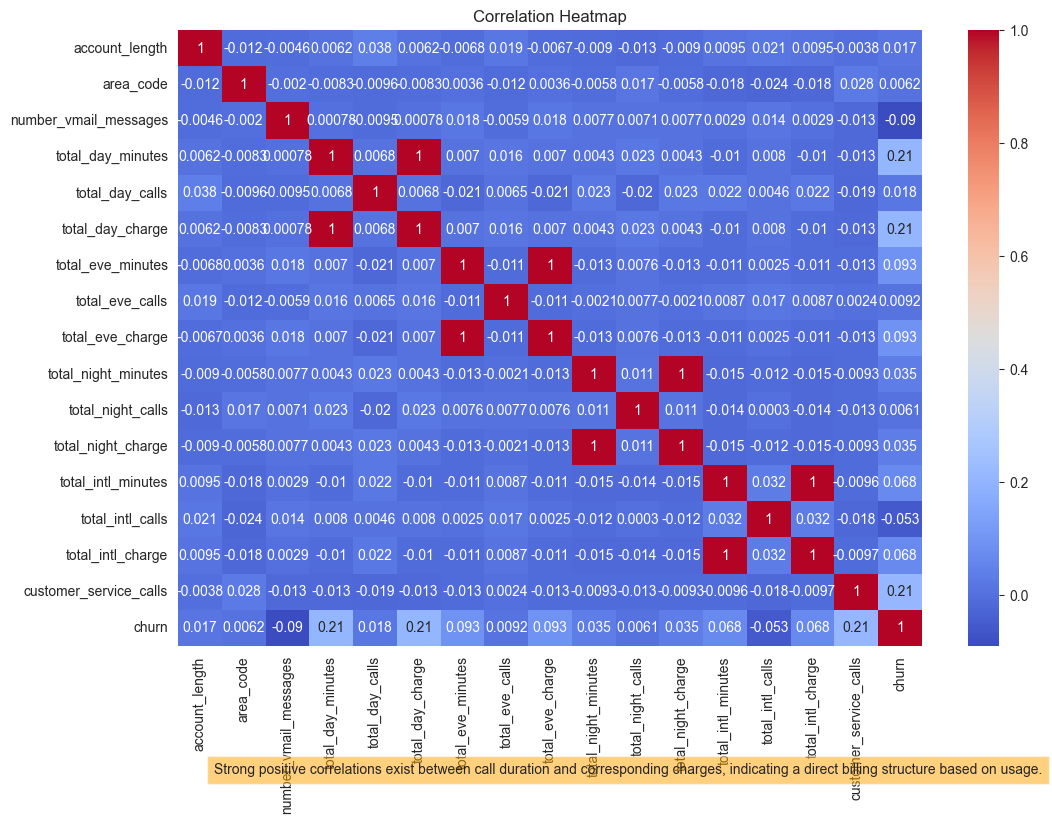

In [22]:
#Chart 6 — Correlation Heatmap 
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.figtext(
    0.5, -0.05,
    "Strong positive correlations exist between call duration and corresponding charges, indicating a direct billing structure based on usage.",
    ha="center",
    fontsize=10,
    bbox={"facecolor":"orange", "alpha":0.5, "pad":5}
)

plt.show()

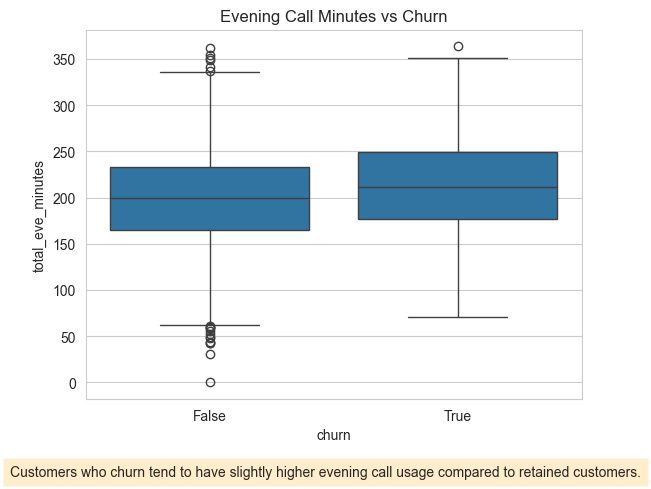

In [23]:
#Chart 7: Evening Minutes vs Churn
sns.boxplot(x='churn', y='total_eve_minutes', data=df)
plt.title("Evening Call Minutes vs Churn")
plt.figtext(0.5,-0.05,
            "Customers who churn tend to have slightly higher evening call usage compared to retained customers.",
            ha="center",fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()


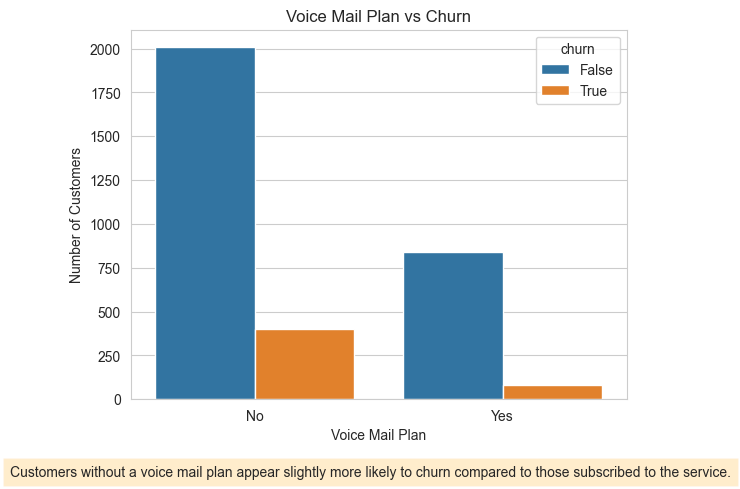

File exported successfully: voicemail_plan_churn.csv


In [24]:

#Chart 8: Voice Mail Plan vs Churn

Voicemail_plan_churn = df.groupby(['voice_mail_plan', 'churn']).size().reset_index(name='count')

sns.countplot(x='voice_mail_plan', hue='churn', data=df)
plt.title("Voice Mail Plan vs Churn")
plt.xlabel("Voice Mail Plan")
plt.ylabel("Number of Customers")
plt.figtext(
    0.5, -0.05,
    "Customers without a voice mail plan appear slightly more likely to churn compared to those subscribed to the service.",
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}
)
plt.show()

# Export
Voicemail_plan_churn.to_csv("voicemail_plan_churn.csv", index=False)
print("File exported successfully: voicemail_plan_churn.csv")



In [25]:
# INSIGHTS, CONCLUSION AND NEXT STEPS

print("INSIGHTS:\n")
print("""
1. Customer Service Calls: Frequent contacts to customer service increase churn likelihood.
2. International Plan Subscribers: Customers with international plans show higher churn rates.
3. Call Usage Patterns: Higher daytime and evening call usage slightly increase churn probability.
4. Billing Charges: Strong positive correlation with call duration, indicating usage-driven charges.
5. Regional Differences: Certain states have higher churn rates, suggesting regional service or competition issues.
6. Voice Mail Plan: Customers without a voice mail plan are slightly more likely to churn.
""")


print("CONCLUSION:\n")
print( """
-The EDA revealed key behavioral and service-related factors influencing customer churn.
-Frequent customer service interactions, international plan subscriptions, and higher call usage,
 are significant drivers. Billing patterns and regional differences also impact retention. 
-These insights can help telecom companies implement targeted retention strategies, optimize plans, 
 and focus on high-risk segments to reduce churn and improve overall customer satisfaction.
""")


print("NEXT STEPS:\n")
print("""
1. Target high-risk customers with proactive support and loyalty programs.
2. Review pricing and value for international plan subscribers to reduce churn.
3. Investigate regions with high churn and improve service quality.
4. Promote optional services like voice mail to improve retention.
5. Build predictive churn models using the identified factors.
""")

INSIGHTS:


1. Customer Service Calls: Frequent contacts to customer service increase churn likelihood.
2. International Plan Subscribers: Customers with international plans show higher churn rates.
3. Call Usage Patterns: Higher daytime and evening call usage slightly increase churn probability.
4. Billing Charges: Strong positive correlation with call duration, indicating usage-driven charges.
5. Regional Differences: Certain states have higher churn rates, suggesting regional service or competition issues.
6. Voice Mail Plan: Customers without a voice mail plan are slightly more likely to churn.

CONCLUSION:


-The EDA revealed key behavioral and service-related factors influencing customer churn.
-Frequent customer service interactions, international plan subscriptions, and higher call usage,
 are significant drivers. Billing patterns and regional differences also impact retention. 
-These insights can help telecom companies implement targeted retention strategies, optimize plans, 